# 🧠 Red de Función de Base Radial (RBF) — Clasificación
### Examen Práctico IA — Implementación Completa

---

## ¿Qué es una Red RBF?

Una **Red de Función de Base Radial (RBF)** es un tipo de red neuronal que clasifica datos basándose en la **distancia** entre un punto y ciertos puntos de referencia llamados **centros**.

La idea es:
1. Encontrar **centros** (puntos representativos de cada grupo usando K-Means)
2. Calcular qué tan **cerca** está cada dato de esos centros usando una función gaussiana
3. Con esas cercanías, **clasificar** el dato

La función gaussiana que se usa es:
$$\phi(x, c) = e^{-\frac{||x - c||^2}{2\sigma^2}}$$

- `x` = dato de entrada
- `c` = centro
- `σ` (sigma) = ancho de la campana gaussiana
- El resultado es un número entre 0 y 1: **1** si está muy cerca del centro, **0** si está muy lejos

---

---
## Importar librerías

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# =====================================================
# IMPORTACIÓN DE LIBRERÍAS
# =====================================================

import json                          
import numpy as np                   
import pandas as pd                  
import matplotlib.pyplot as plt      
import matplotlib.gridspec as gridspec
import seaborn as sns               
import warnings
warnings.filterwarnings('ignore')


from sklearn.cluster import KMeans                      
from sklearn.preprocessing import StandardScaler        
from sklearn.linear_model import LogisticRegression     
from sklearn.metrics import (
    confusion_matrix,          
    accuracy_score,            
    precision_score,          
    recall_score,              
    f1_score,                  
    classification_report      
)
from sklearn.model_selection import train_test_split   

# Configuración de gráficas
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Librerías importadas correctamente')

Librerías importadas correctamente


---
## Clase RBF (El Motor Principal)

In [3]:
class RedRBF:
    def __init__(self, n_centros=10, sigma=None, C=1.0, random_state=42):
        self.n_centros = n_centros
        self.sigma = sigma
        self.C = C
        self.random_state = random_state
        
        self.centros_ = None        
        self.sigma_calc_ = None     
        self.clasificador_ = None   
        self.scaler_ = StandardScaler()  
    
    def _normalizar(self, X, fit=False):
        if fit:
            return self.scaler_.fit_transform(X)
        return self.scaler_.transform(X)
    
    def _encontrar_centros(self, X):
        kmeans = KMeans(
            n_clusters=self.n_centros,
            random_state=self.random_state,
            n_init=10
        )
        kmeans.fit(X)
        return kmeans.cluster_centers_   
    
    def _calcular_sigma(self, centros):
        max_dist = 0
        for i in range(len(centros)):
            for j in range(i+1, len(centros)):
                dist = np.linalg.norm(centros[i] - centros[j])
                if dist > max_dist:
                    max_dist = dist
        sigma = max_dist / np.sqrt(2 * self.n_centros)
        return max(sigma, 1e-6)  
    
    def _activaciones_rbf(self, X):
        activaciones = np.zeros((X.shape[0], self.n_centros))
        for j, centro in enumerate(self.centros_):
            dist_sq = np.sum((X - centro) ** 2, axis=1)
            activaciones[:, j] = np.exp(-dist_sq / (2 * self.sigma_calc_ ** 2))
        return activaciones
    
    def fit(self, X_train, y_train):
        # 1. Normalizar los datos de entrenamiento
        X_norm = self._normalizar(X_train, fit=True)
        
        # 2. Encontrar centros con K-Means
        self.centros_ = self._encontrar_centros(X_norm)
        
        # 3. Calcular sigma
        if self.sigma is None:
            self.sigma_calc_ = self._calcular_sigma(self.centros_)
        else:
            self.sigma_calc_ = self.sigma
        
        # 4. Calcular activaciones RBF para datos de entrenamiento
        phi_train = self._activaciones_rbf(X_norm)
        
        # 5. Entrenar el clasificador de salida
        self.clasificador_ = LogisticRegression(
            C=self.C,
            max_iter=1000,
            random_state=self.random_state,
        )
        self.clasificador_.fit(phi_train, y_train)
        return self
    
    def predict(self, X):
        X_norm = self._normalizar(X)
        phi = self._activaciones_rbf(X_norm)
        return self.clasificador_.predict(phi)
    
    def predict_proba(self, X):
        X_norm = self._normalizar(X)
        phi = self._activaciones_rbf(X_norm)
        return self.clasificador_.predict_proba(phi)

print('Clase RedRBF definida correctamente')

Clase RedRBF definida correctamente


---
## Funciones de Apoyo (Métricas y Gráficas)

In [4]:
def cargar_dataset(ruta_json):
    with open(ruta_json, 'r') as f:
        datos = json.load(f)
    
    X = np.array([d['input'] for d in datos['data']])
    y = np.array([d['output'] for d in datos['data']])
    features = datos['features']
    nombre = datos['dataset']
    
    return X, y, features, nombre


def estadistica_descriptiva(X, y, features, nombre):
    print(f'\n{'='*60}')
    print(f'  ESTADÍSTICA DESCRIPTIVA — {nombre}')
    print(f'{'='*60}')
    print(f'  • Total de muestras : {len(X)}')
    print(f'  • Número de features: {X.shape[1]} → {features}')
    print(f'  • Clases            : {np.unique(y)}')
    
    conteo = {c: np.sum(y==c) for c in np.unique(y)}
    print(f'  • Muestras por clase: {conteo}')
    
    df = pd.DataFrame(X, columns=features)
    df['clase'] = y
    
    print('\n  Estadísticas por variable:')
    desc = df[features].describe().round(3)
    print(desc.to_string())
    
    print('\n  Media por clase:')
    print(df.groupby('clase')[features].mean().round(3).to_string())
    
    return df


def mostrar_metricas(y_true, y_pred, nombre_conjunto=''):
    clases = np.unique(y_true)
    avg = 'binary' if len(clases) == 2 else 'macro'
    
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=avg, zero_division=0)
    rec  = recall_score(y_true, y_pred, average=avg, zero_division=0)
    f1   = f1_score(y_true, y_pred, average=avg, zero_division=0)
    
    print(f'\n  📊 MÉTRICAS — {nombre_conjunto}')
    print(f'  ┌─────────────────────────────────────┐')
    print(f'  │  Exactitud   (Accuracy)  : {acc:.4f}  │')
    print(f'  │  Precisión   (Precision) : {prec:.4f}  │')
    print(f'  │  Sensibilidad (Recall)   : {rec:.4f}  │')
    print(f'  │  F1 Score                : {f1:.4f}  │')
    print(f'  └─────────────────────────────────────┘')
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


def graficar_matriz_confusion(y_true, y_pred, clases, titulo=''):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=[f'Pred {c}' for c in clases],
        yticklabels=[f'Real {c}' for c in clases],
        linewidths=0.5
    )
    plt.title(f'Matriz de Confusión — {titulo}', fontsize=13, fontweight='bold')
    plt.ylabel('Clase Real', fontsize=11)
    plt.xlabel('Clase Predicha', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # Interpretación automática
    total = cm.sum()
    correctos = cm.diagonal().sum()
    print(f'  → {correctos}/{total} muestras clasificadas correctamente ({correctos/total*100:.1f}%)')
    for i, c in enumerate(clases):
        tp = cm[i,i]
        real_total = cm[i,:].sum()
        print(f'  → Clase {c}: detectó {tp}/{real_total} correctamente ({tp/real_total*100:.1f}%)')


def graficar_activaciones_rbf(modelo, X, y, features, titulo=''):
    X_norm = modelo.scaler_.transform(X)
    phi = modelo._activaciones_rbf(X_norm)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Heatmap de activaciones (muestra primeras 50 muestras)
    ax = axes[0]
    idx = np.random.choice(len(phi), min(50, len(phi)), replace=False)
    muestra = phi[idx]
    im = ax.imshow(muestra, aspect='auto', cmap='hot', interpolation='nearest')
    plt.colorbar(im, ax=ax)
    ax.set_xlabel('Neurona RBF (centro)', fontsize=11)
    ax.set_ylabel('Muestra de dato', fontsize=11)
    ax.set_title(f'Activaciones RBF\n(50 muestras aleatorias)', fontsize=11, fontweight='bold')
    
    # Activación promedio por neurona
    ax = axes[1]
    act_media = phi.mean(axis=0)
    colores = plt.cm.viridis(np.linspace(0, 1, len(act_media)))
    barras = ax.bar(range(len(act_media)), act_media, color=colores, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Índice del centro RBF', fontsize=11)
    ax.set_ylabel('Activación promedio', fontsize=11)
    ax.set_title('Activación Promedio\nde cada Neurona RBF', fontsize=11, fontweight='bold')
    ax.axhline(act_media.mean(), color='red', linestyle='--', label=f'Media: {act_media.mean():.3f}')
    ax.legend()
    
    plt.suptitle(f'{titulo}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def graficar_centros_vs_datos(modelo, X, y, features, titulo=''):
    X_norm = modelo.scaler_.transform(X)
    centros = modelo.centros_
    clases = np.unique(y)
    colores_clase = plt.cm.Set1(np.linspace(0, 0.8, len(clases)))
    
    plt.figure(figsize=(8, 6))
    
    for i, c in enumerate(clases):
        mask = y == c
        plt.scatter(
            X_norm[mask, 0], X_norm[mask, 1],
            c=[colores_clase[i]], alpha=0.3, s=20, label=f'Clase {c}'
        )
    
    # Centros RBF
    plt.scatter(
        centros[:, 0], centros[:, 1],
        c='black', marker='*', s=300, zorder=5, label=f'{len(centros)} Centros RBF'
    )
    
    plt.xlabel(f'{features[0]} (normalizado)', fontsize=11)
    plt.ylabel(f'{features[1]} (normalizado)', fontsize=11)
    plt.title(f'Datos y Centros RBF — {titulo}\n(Proyección en {features[0]} vs {features[1]})',
              fontsize=12, fontweight='bold')
    plt.legend(markerscale=1.5)
    plt.tight_layout()
    plt.show()


def graficar_comparacion_resultados(resultados_lista, titulo=''):
    conjuntos = list(resultados_lista[0][1].keys())
    metricas = ['accuracy', 'precision', 'recall', 'f1']
    nombres_metricas = ['Exactitud', 'Precisión', 'Sensibilidad', 'F1 Score']
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    
    for idx, (metrica, nombre) in enumerate(zip(metricas, nombres_metricas)):
        ax = axes[idx]
        x = np.arange(len(conjuntos))
        width = 0.35
        
        for i, (etiqueta, res) in enumerate(resultados_lista):
            vals = [res[conj][metrica] for conj in conjuntos]
            offset = (i - len(resultados_lista)/2 + 0.5) * width
            bars = ax.bar(x + offset, vals, width*0.9,
                          label=etiqueta,
                          color=plt.cm.Set2(i / max(len(resultados_lista)-1, 1)),
                          edgecolor='black', linewidth=0.5)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        
        ax.set_xticks(x)
        ax.set_xticklabels(conjuntos, fontsize=10)
        ax.set_ylabel(nombre)
        ax.set_title(nombre, fontweight='bold')
        ax.set_ylim(0, 1.12)
        ax.legend(fontsize=8)
        ax.axhline(1.0, color='green', linestyle=':', linewidth=0.8, alpha=0.7)
    
    plt.suptitle(f'Comparación de Resultados — {titulo}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def pipeline_completo(ruta_json, n_centros=10, sigma=None, C=1.0,
                       particion='80-10-10', random_state=42,
                       nombre_version='v1'):
    print(f'\n{"#"*65}')
    print(f'  PIPELINE RBF — {nombre_version}')
    print(f'{"#"*65}')
    
    # =====================
    # PASO 1: Cargar dataset
    # =====================
    print('\nCargando dataset...')
    X, y, features, nombre_ds = cargar_dataset(ruta_json)
    print(f'   Dataset: {nombre_ds}')
    print(f'   Forma de X: {X.shape}  (filas=muestras, columnas=variables)')
    print(f'   Clases en y: {np.unique(y)}')
    
    # ============================
    # PASO 2: Parámetros de entrada
    # ============================
    print('\nParámetros de entrada definidos:')
    print(f'   • n_centros    = {n_centros}  (neuronas en la capa RBF)')
    print(f'   • sigma        = {sigma if sigma else "automático"}')
    print(f'   • C (regulariz)= {C}')
    print(f'   • Partición    = {particion}')
    print(f'   • random_state = {random_state}')
    
    # ==============================
    # PASO 3: Estadística descriptiva
    # ==============================
    print('\nEstadística descriptiva:')
    df = estadistica_descriptiva(X, y, features, nombre_ds)
    
    # ==============================
    # PASO 4: Particionamiento
    # ==============================
    print(f'\nParticionamiento ({particion}):')
    
    if particion == '80-10-10':
        train_size, val_size, test_size = 0.80, 0.10, 0.10
    elif particion == '70-15-15':
        train_size, val_size, test_size = 0.70, 0.15, 0.15
    else:
        raise ValueError('Partición no válida. Usa: 80-10-10 o 70-15-15')
    
    # Dividir: primero separar test, luego val del resto
    X_tmp, X_test, y_tmp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    val_relativa = val_size / (train_size + val_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tmp, y_tmp, test_size=val_relativa, random_state=random_state, stratify=y_tmp
    )
    
    print(f'   • Entrenamiento: {len(X_train)} muestras ({len(X_train)/len(X)*100:.0f}%)')
    print(f'   • Validación   : {len(X_val)} muestras ({len(X_val)/len(X)*100:.0f}%)')
    print(f'   • Prueba (Test): {len(X_test)} muestras ({len(X_test)/len(X)*100:.0f}%)')
    print(f'   NOTA: Se usa stratify=y para que cada partición tenga la misma')
    print(f'         proporción de clases que el dataset original.')
    
    # ================================
    # PASO 5: Parámetros de entrenamiento
    # ================================
    print('\nParámetros de entrenamiento confirmados:')
    print(f'   La RBF tiene {n_centros} centros. K-Means buscará {n_centros} grupos')
    print(f'   en los {len(X_train)} datos de entrenamiento.')
    print(f'   Sigma: {"será calculado automáticamente" if sigma is None else sigma}')
    print(f'   La capa de salida es una Regresión Logística con C={C}')
    
    # ========================
    # PASO 6: Entrenar el modelo
    # ========================
    print('\nEntrenando la red RBF...')
    modelo = RedRBF(n_centros=n_centros, sigma=sigma, C=C, random_state=random_state)
    modelo.fit(X_train, y_train)
    print(f'   Entrenamiento completo!')
    print(f'   • Sigma calculado : {modelo.sigma_calc_:.4f}')
    print(f'   • Centros RBF     : {modelo.centros_.shape[0]} centros de dim {modelo.centros_.shape[1]}')
    
    # Graficar centros
    graficar_centros_vs_datos(modelo, X_train, y_train, features,
                               f'{nombre_ds} — {nombre_version}')
    
    # ========================
    # PASO 7: Simular (predecir)
    # ========================
    print('\nSimulando (prediciendo) en los 3 conjuntos:')
    y_pred_train = modelo.predict(X_train)
    y_pred_val   = modelo.predict(X_val)
    y_pred_test  = modelo.predict(X_test)
    
    # Ejemplo de predicciones individuales
    print('   Ejemplo (primeras 5 muestras del conjunto de validación):')
    print(f'   Real    : {y_val[:5]}')
    print(f'   Predicho: {y_pred_val[:5]}')
    
    # ========================
    # PASO 8: Métricas
    # ========================
    print('\nMétricas de evaluación:')
    metricas_train = mostrar_metricas(y_train, y_pred_train, 'ENTRENAMIENTO')
    metricas_val   = mostrar_metricas(y_val,   y_pred_val,   'VALIDACIÓN')
    metricas_test  = mostrar_metricas(y_test,  y_pred_test,  'PRUEBA (TEST)')
    
    clases = np.unique(y)
    print('\n  Reporte detallado por clase (conjunto Test):')
    print(classification_report(y_test, y_pred_test, zero_division=0))
    
    # ========================
    # PASO 9: Gráficas
    # ========================
    print('\nGráficas de resultados:')
    
    # Matrices de confusión
    fig, axes_cm = plt.subplots(1, 3, figsize=(16, 5))
    nombres_cm = ['Entrenamiento', 'Validación', 'Test']
    pares = [(y_train, y_pred_train), (y_val, y_pred_val), (y_test, y_pred_test)]
    
    for ax, (yt, yp), nom in zip(axes_cm, pares, nombres_cm):
        cm = confusion_matrix(yt, yp)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=[f'P{c}' for c in clases],
                    yticklabels=[f'R{c}' for c in clases])
        acc = accuracy_score(yt, yp)
        ax.set_title(f'{nom}\nAccuracy: {acc:.3f}', fontweight='bold')
        ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    
    plt.suptitle(f'Matrices de Confusión — {nombre_ds} {nombre_version}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Gráfica de barras de métricas
    metricas_nombres = ['accuracy', 'precision', 'recall', 'f1']
    etiquetas = ['Exactitud', 'Precisión', 'Sensibilidad', 'F1']
    x = np.arange(len(metricas_nombres))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (mets, nom, color) in enumerate([
        (metricas_train, 'Entrenamiento', '#2196F3'),
        (metricas_val,   'Validación',    '#FF9800'),
        (metricas_test,  'Test',          '#4CAF50')
    ]):
        vals = [mets[m] for m in metricas_nombres]
        bars = ax.bar(x + (i-1)*width, vals, width, label=nom, color=color,
                      edgecolor='black', linewidth=0.5)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas, fontsize=11)
    ax.set_ylabel('Valor de la métrica', fontsize=11)
    ax.set_title(f'Comparación de Métricas — {nombre_ds} {nombre_version}',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.legend()
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
    plt.tight_layout()
    plt.show()
    
    # Activaciones RBF
    graficar_activaciones_rbf(modelo, X_test, y_test, features,
                               f'{nombre_ds} — Activaciones RBF {nombre_version}')
    
    resultado = {
        'train': metricas_train,
        'val': metricas_val,
        'test': metricas_test
    }
    
    return modelo, resultado

print('Funciones de apoyo definidas correctamente')

Funciones de apoyo definidas correctamente


---
# DATASET 1 — Clasificación Binaria (2 clases)
**Contexto:** Pacientes con condición normal (clase 0) vs alterada (clase 1)  
**Variables:** x1, x2, x3, x4 (4 variables)  
**Datos:** 1000 muestras (500 por clase)

---
## Configuracion de los parámetros del Dataset 1

**¿Qué cambia cada parámetro?**
- `n_centros`: Cuántas neuronas tiene la capa RBF. Empieza con 6-10 y prueba más.
- `sigma`: La 'amplitud' de cada neurona. `None` = cálculo automático (recomendado al inicio).
- `C`: Qué tan compleja puede ser la frontera de decisión. Valor típico: 0.1 a 10.
- `particion`: `'80-10-10'` o `'70-15-15'`

In [5]:
RUTA_DS1 = 'dataset_rbf_1.json'   

PARAMS_DS1_V1 = {
    'n_centros'   : 8,           
    'sigma'       : None,        
    'C'           : 1.0,         
    'particion'   : '80-10-10',  
    'random_state': 42           
}


#################################################################
  PIPELINE RBF — Versión 1
#################################################################

Cargando dataset...
   Dataset: clasificacion_2_clases_grande
   Forma de X: (1000, 4)  (filas=muestras, columnas=variables)
   Clases en y: [0 1]

Parámetros de entrada definidos:
   • n_centros    = 8  (neuronas en la capa RBF)
   • sigma        = automático
   • C (regulariz)= 1.0
   • Partición    = 80-10-10
   • random_state = 42

Estadística descriptiva:

  ESTADÍSTICA DESCRIPTIVA — clasificacion_2_clases_grande
  • Total de muestras : 1000
  • Número de features: 4 → ['x1', 'x2', 'x3', 'x4']
  • Clases            : [0 1]
  • Muestras por clase: {np.int64(0): np.int64(500), np.int64(1): np.int64(500)}

  Estadísticas por variable:
             x1        x2        x3        x4
count  1000.000  1000.000  1000.000  1000.000
mean      3.491     3.471     3.546     3.468
std       2.601     2.597     2.610     2.604
min      -

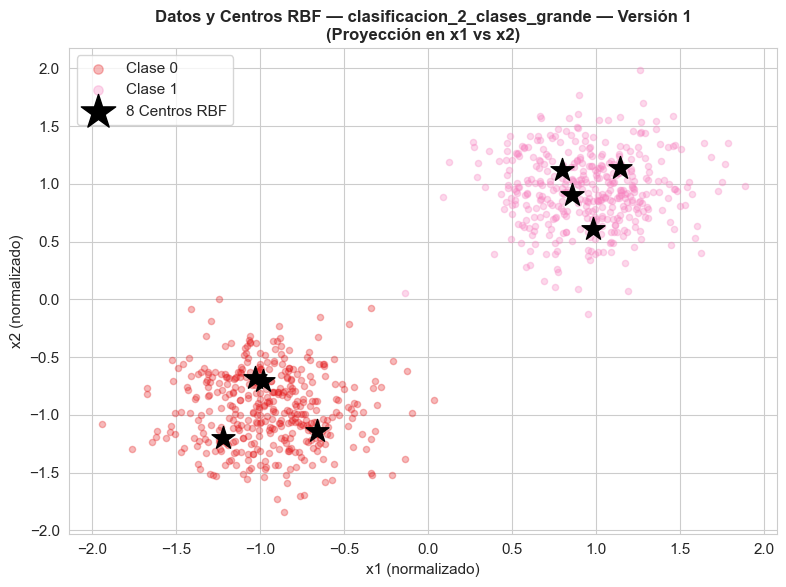


Simulando (prediciendo) en los 3 conjuntos:
   Ejemplo (primeras 5 muestras del conjunto de validación):
   Real    : [0 1 1 0 0]
   Predicho: [0 1 1 0 0]

Métricas de evaluación:

  📊 MÉTRICAS — ENTRENAMIENTO
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └─────────────────────────────────────┘

  📊 MÉTRICAS — VALIDACIÓN
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └─────────────────────────────────────┘

  📊 MÉTRICAS — PRUEBA (TEST)
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └───────────────────────────

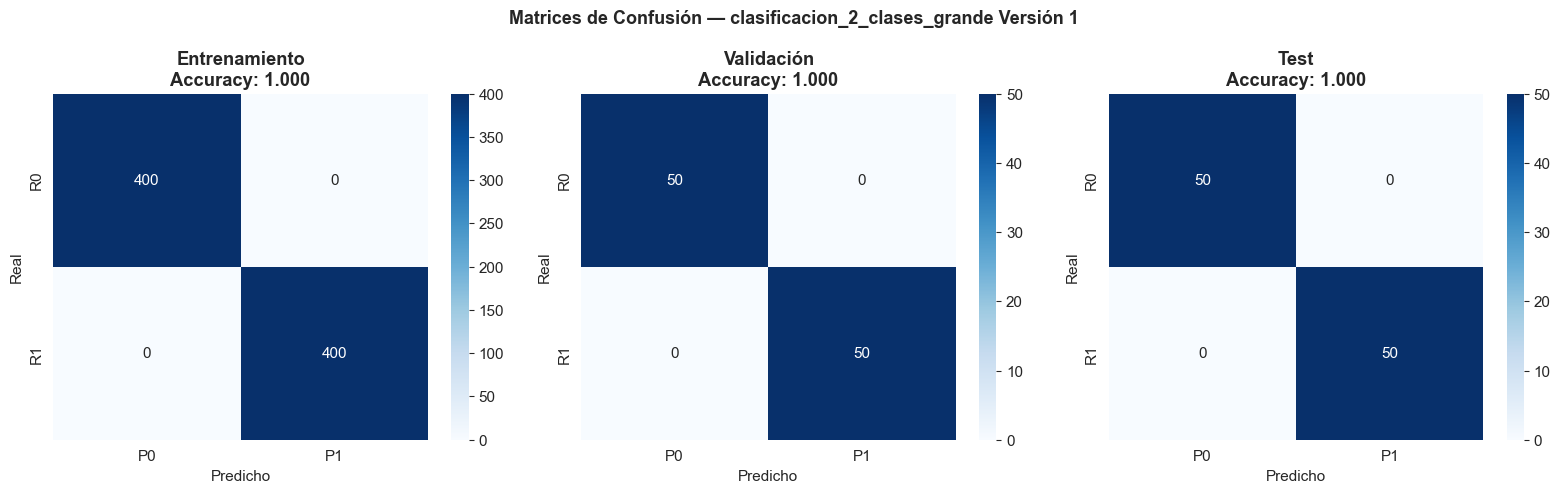

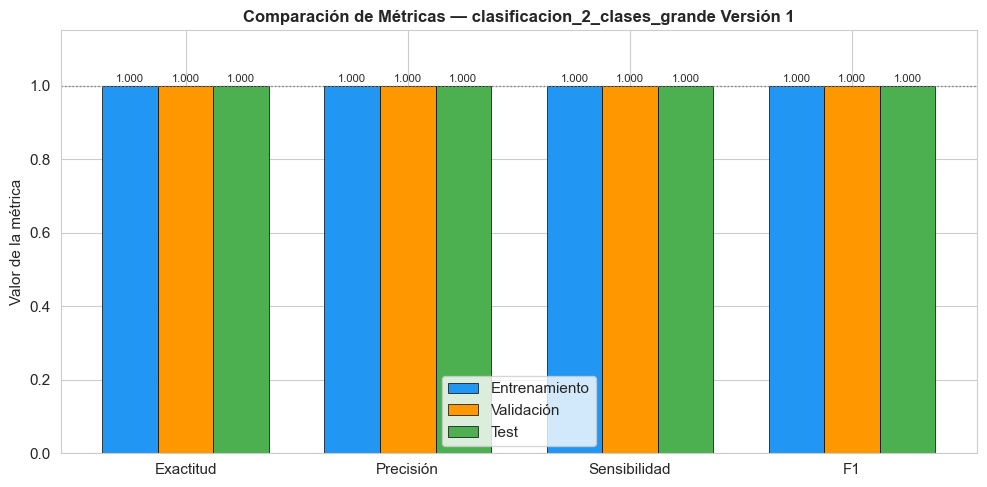

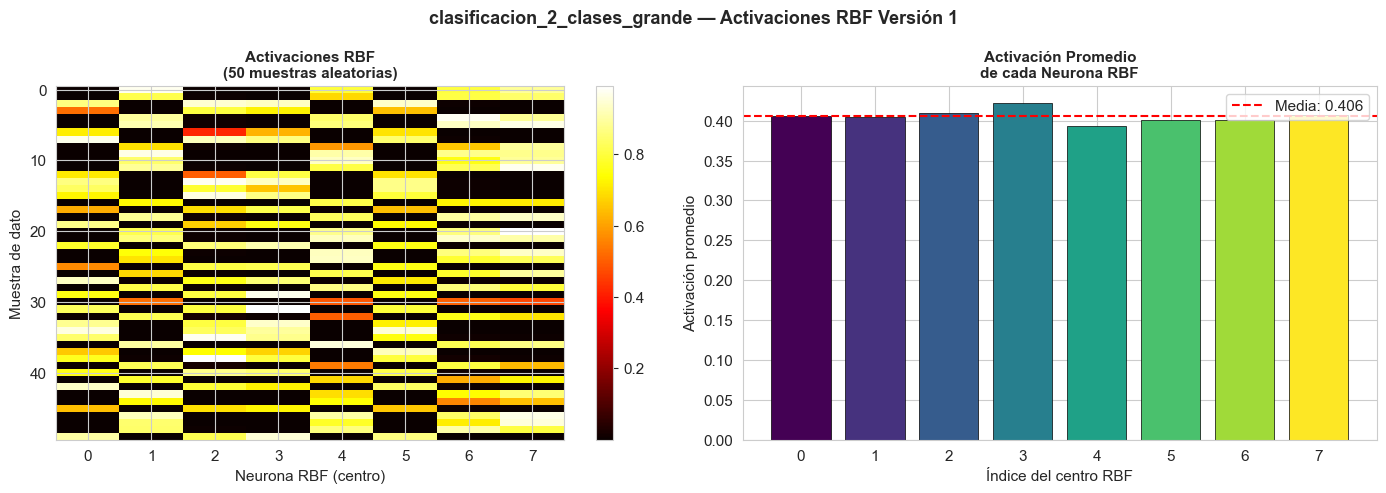

In [6]:
# Ejecucion del pipeline completo para Dataset 1 — Versión 1
modelo_ds1_v1, metricas_ds1_v1 = pipeline_completo(
    RUTA_DS1,
    nombre_version='Versión 1',
    **PARAMS_DS1_V1
)

---
## Dataset 1: Ajuste de parámetros y re-entrenamiento

Se ajustan los parametros para intentar mejorar los resultados.


#################################################################
  PIPELINE RBF — Versión 2 (ajustada)
#################################################################

Cargando dataset...
   Dataset: clasificacion_2_clases_grande
   Forma de X: (1000, 4)  (filas=muestras, columnas=variables)
   Clases en y: [0 1]

Parámetros de entrada definidos:
   • n_centros    = 16  (neuronas en la capa RBF)
   • sigma        = automático
   • C (regulariz)= 5.0
   • Partición    = 70-15-15
   • random_state = 42

Estadística descriptiva:

  ESTADÍSTICA DESCRIPTIVA — clasificacion_2_clases_grande
  • Total de muestras : 1000
  • Número de features: 4 → ['x1', 'x2', 'x3', 'x4']
  • Clases            : [0 1]
  • Muestras por clase: {np.int64(0): np.int64(500), np.int64(1): np.int64(500)}

  Estadísticas por variable:
             x1        x2        x3        x4
count  1000.000  1000.000  1000.000  1000.000
mean      3.491     3.471     3.546     3.468
std       2.601     2.597     2.610     2.60

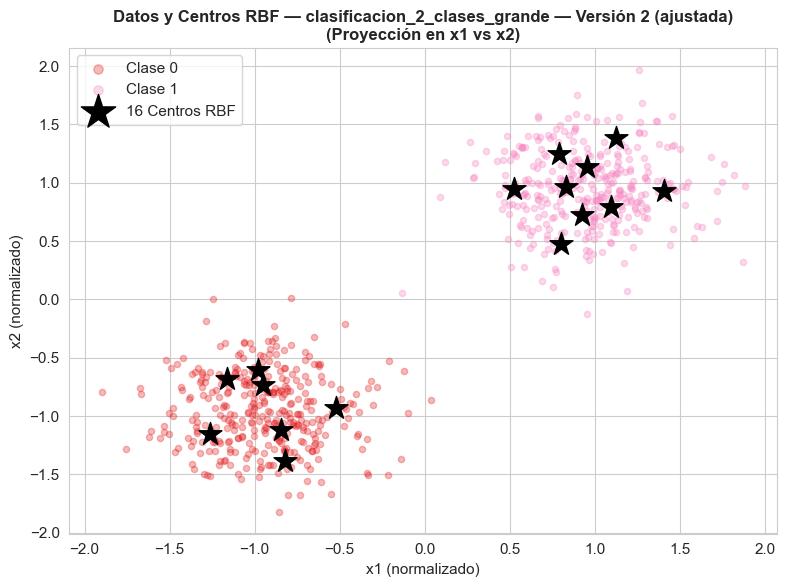


Simulando (prediciendo) en los 3 conjuntos:
   Ejemplo (primeras 5 muestras del conjunto de validación):
   Real    : [0 1 1 0 0]
   Predicho: [0 1 1 0 0]

Métricas de evaluación:

  📊 MÉTRICAS — ENTRENAMIENTO
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └─────────────────────────────────────┘

  📊 MÉTRICAS — VALIDACIÓN
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └─────────────────────────────────────┘

  📊 MÉTRICAS — PRUEBA (TEST)
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └───────────────────────────

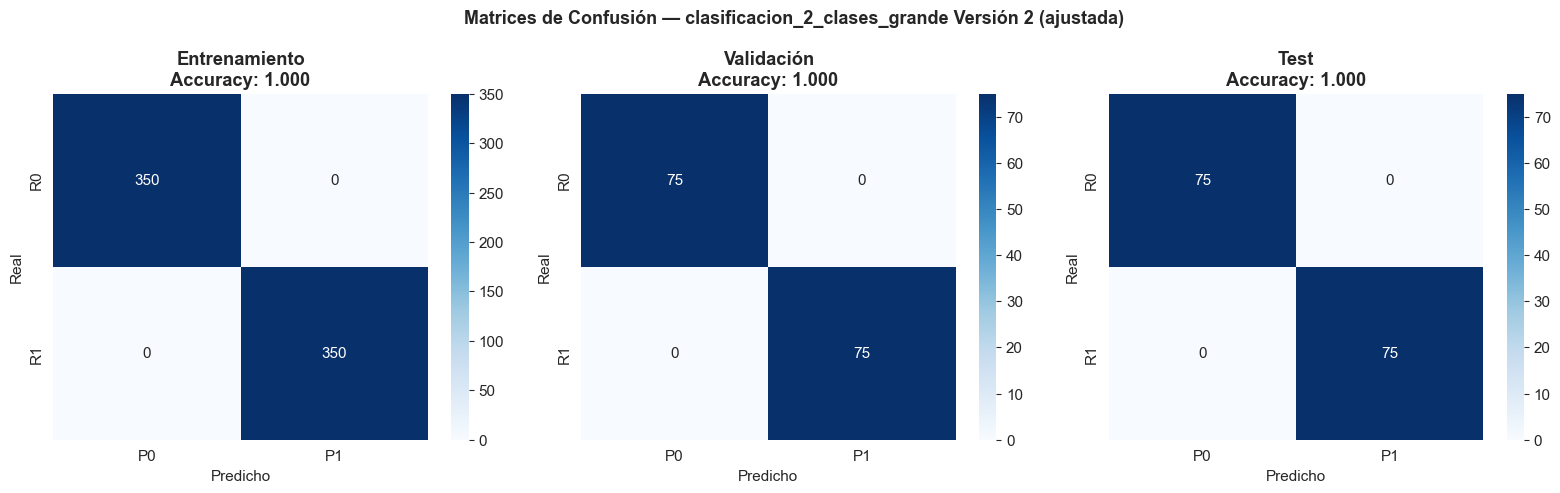

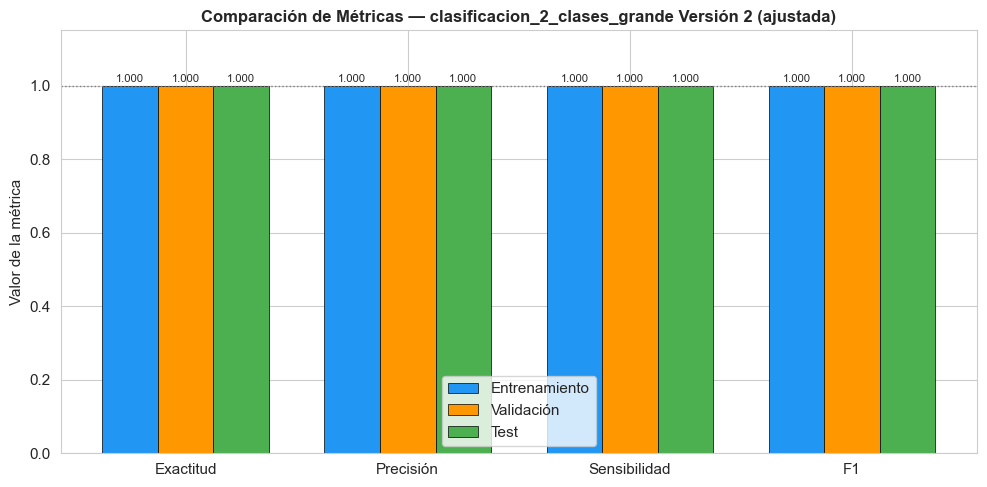

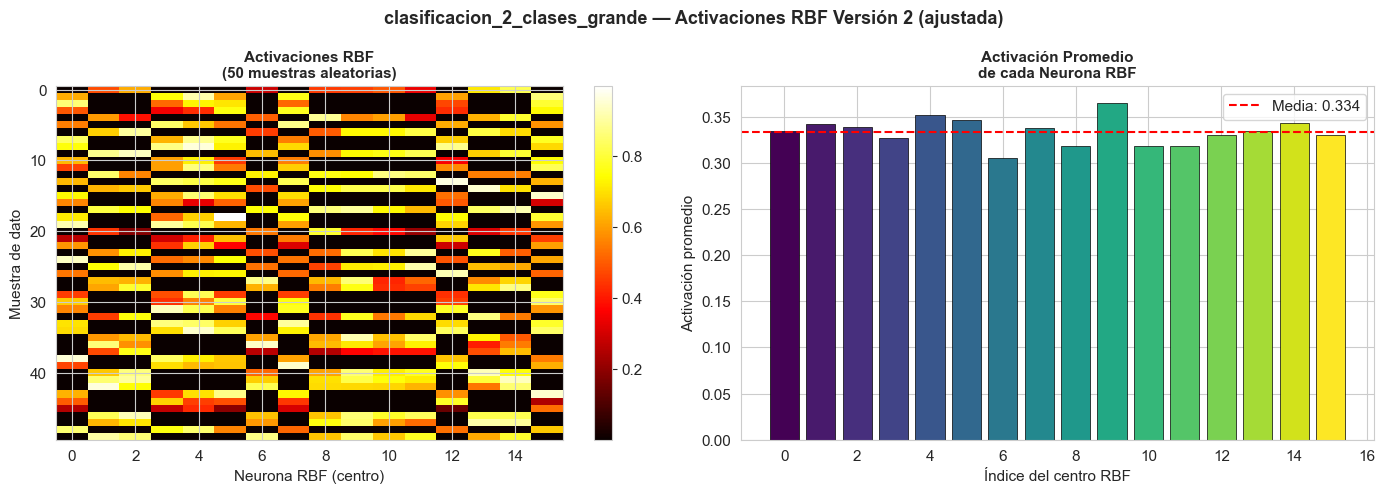

In [7]:
PARAMS_DS1_V2 = {
    'n_centros'   : 16,          
    'sigma'       : None,
    'C'           : 5.0,         
    'particion'   : '70-15-15',  
    'random_state': 42
}

modelo_ds1_v2, metricas_ds1_v2 = pipeline_completo(
    RUTA_DS1,
    nombre_version='Versión 2 (ajustada)',
    **PARAMS_DS1_V2
)


🔍 COMPARACIÓN DATASET 1 — V1 vs V2


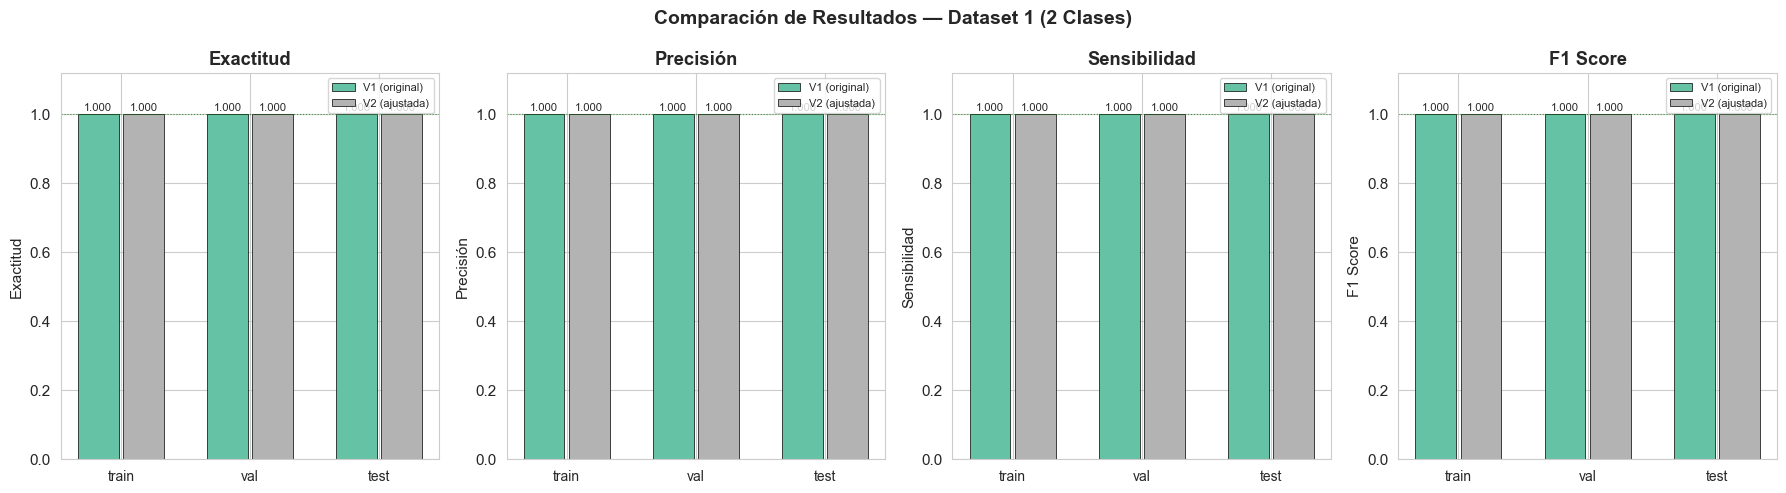


📋 Resumen comparativo:
  V1 → Train: 1.0000 | Val: 1.0000 | Test: 1.0000
  V2 → Train: 1.0000 | Val: 1.0000 | Test: 1.0000


In [8]:
# Comparación visual entre V1 y V2
print('\n🔍 COMPARACIÓN DATASET 1 — V1 vs V2')
graficar_comparacion_resultados(
    [('V1 (original)', metricas_ds1_v1),
     ('V2 (ajustada)', metricas_ds1_v2)],
    titulo='Dataset 1 (2 Clases)'
)

print('\n📋 Resumen comparativo:')
for version, mets in [('V1', metricas_ds1_v1), ('V2', metricas_ds1_v2)]:
    print(f'  {version} → Train: {mets["train"]["accuracy"]:.4f} | '
          f'Val: {mets["val"]["accuracy"]:.4f} | '
          f'Test: {mets["test"]["accuracy"]:.4f}')

---
# DATASET 2 — Clasificación con 3 clases
**Contexto:** Niveles de producción: baja (0), media (1), alta (2)  
**Variables:** x1, x2, x3 (3 variables)  
**Datos:** 1050 muestras (350 por clase)

---


#################################################################
  PIPELINE RBF — Versión 1
#################################################################

Cargando dataset...
   Dataset: clasificacion_3_clases_grande
   Forma de X: (1050, 3)  (filas=muestras, columnas=variables)
   Clases en y: [0 1 2]

Parámetros de entrada definidos:
   • n_centros    = 12  (neuronas en la capa RBF)
   • sigma        = automático
   • C (regulariz)= 1.0
   • Partición    = 80-10-10
   • random_state = 42

Estadística descriptiva:

  ESTADÍSTICA DESCRIPTIVA — clasificacion_3_clases_grande
  • Total de muestras : 1050
  • Número de features: 3 → ['x1', 'x2', 'x3']
  • Clases            : [0 1 2]
  • Muestras por clase: {np.int64(0): np.int64(350), np.int64(1): np.int64(350), np.int64(2): np.int64(350)}

  Estadísticas por variable:
             x1        x2        x3
count  1050.000  1050.000  1050.000
mean      4.998     5.008     5.009
std       3.337     3.352     3.360
min      -1.668    -1.1

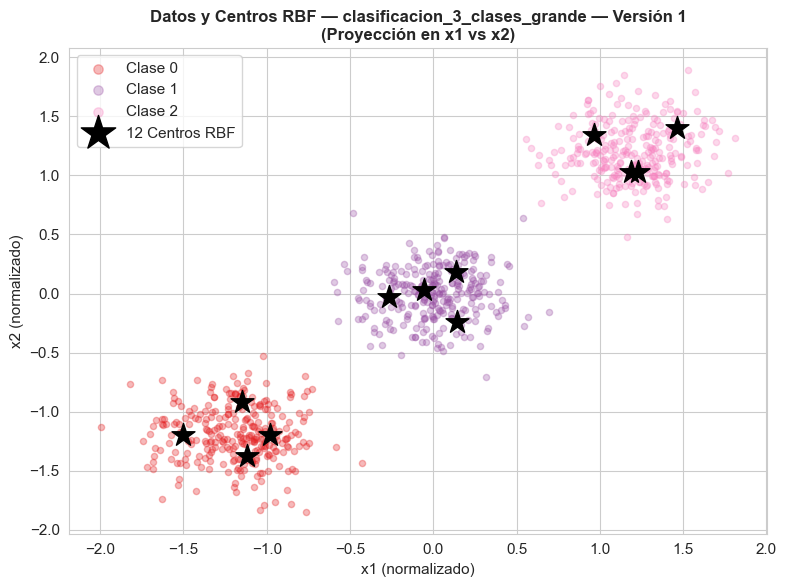


Simulando (prediciendo) en los 3 conjuntos:
   Ejemplo (primeras 5 muestras del conjunto de validación):
   Real    : [2 0 2 2 2]
   Predicho: [2 0 2 2 2]

Métricas de evaluación:

  📊 MÉTRICAS — ENTRENAMIENTO
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └─────────────────────────────────────┘

  📊 MÉTRICAS — VALIDACIÓN
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └─────────────────────────────────────┘

  📊 MÉTRICAS — PRUEBA (TEST)
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └───────────────────────────

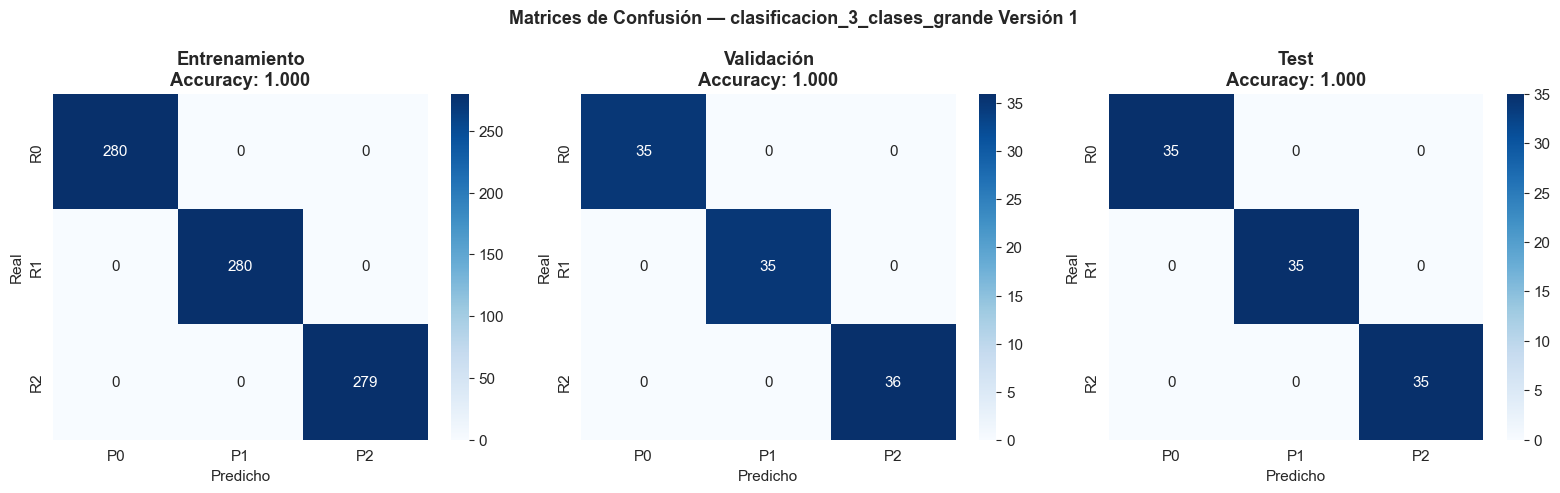

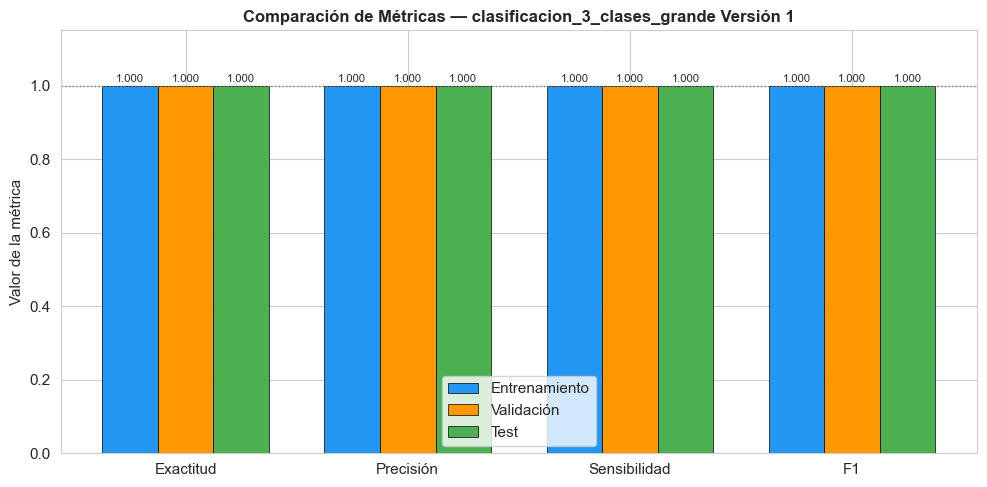

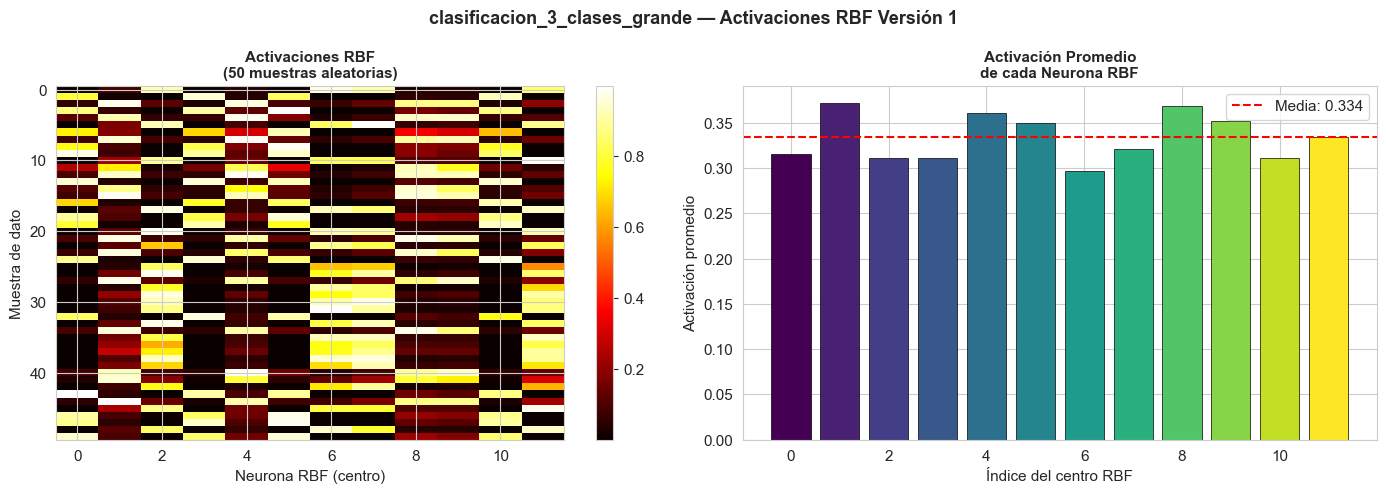

In [9]:
RUTA_DS2 = 'dataset_rbf_2.json'  

PARAMS_DS2_V1 = {
    'n_centros'   : 12,         
    'sigma'       : None,
    'C'           : 1.0,
    'particion'   : '80-10-10',
    'random_state': 42
}

modelo_ds2_v1, metricas_ds2_v1 = pipeline_completo(
    RUTA_DS2,
    nombre_version='Versión 1',
    **PARAMS_DS2_V1
)


#################################################################
  PIPELINE RBF — Versión 2 (ajustada)
#################################################################

Cargando dataset...
   Dataset: clasificacion_3_clases_grande
   Forma de X: (1050, 3)  (filas=muestras, columnas=variables)
   Clases en y: [0 1 2]

Parámetros de entrada definidos:
   • n_centros    = 24  (neuronas en la capa RBF)
   • sigma        = automático
   • C (regulariz)= 10.0
   • Partición    = 70-15-15
   • random_state = 42

Estadística descriptiva:

  ESTADÍSTICA DESCRIPTIVA — clasificacion_3_clases_grande
  • Total de muestras : 1050
  • Número de features: 3 → ['x1', 'x2', 'x3']
  • Clases            : [0 1 2]
  • Muestras por clase: {np.int64(0): np.int64(350), np.int64(1): np.int64(350), np.int64(2): np.int64(350)}

  Estadísticas por variable:
             x1        x2        x3
count  1050.000  1050.000  1050.000
mean      4.998     5.008     5.009
std       3.337     3.352     3.360
min      -1

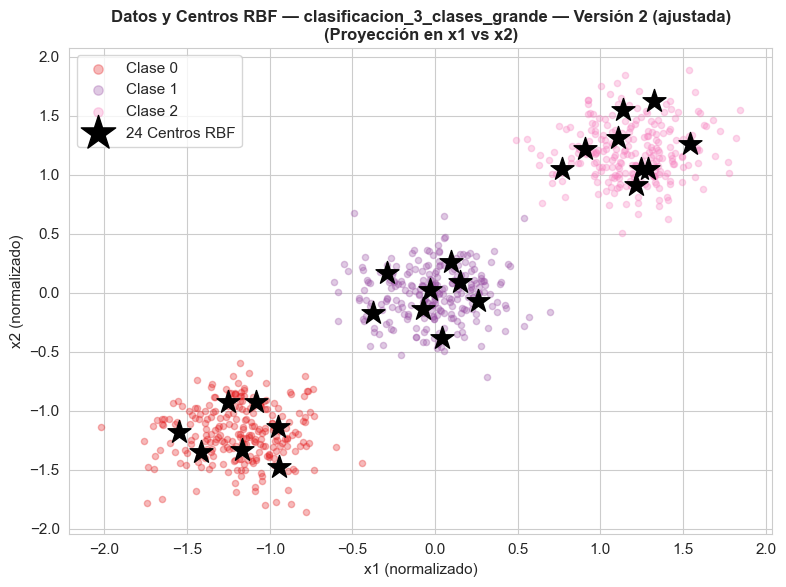


Simulando (prediciendo) en los 3 conjuntos:
   Ejemplo (primeras 5 muestras del conjunto de validación):
   Real    : [0 0 0 2 2]
   Predicho: [0 0 0 2 2]

Métricas de evaluación:

  📊 MÉTRICAS — ENTRENAMIENTO
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └─────────────────────────────────────┘

  📊 MÉTRICAS — VALIDACIÓN
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └─────────────────────────────────────┘

  📊 MÉTRICAS — PRUEBA (TEST)
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └───────────────────────────

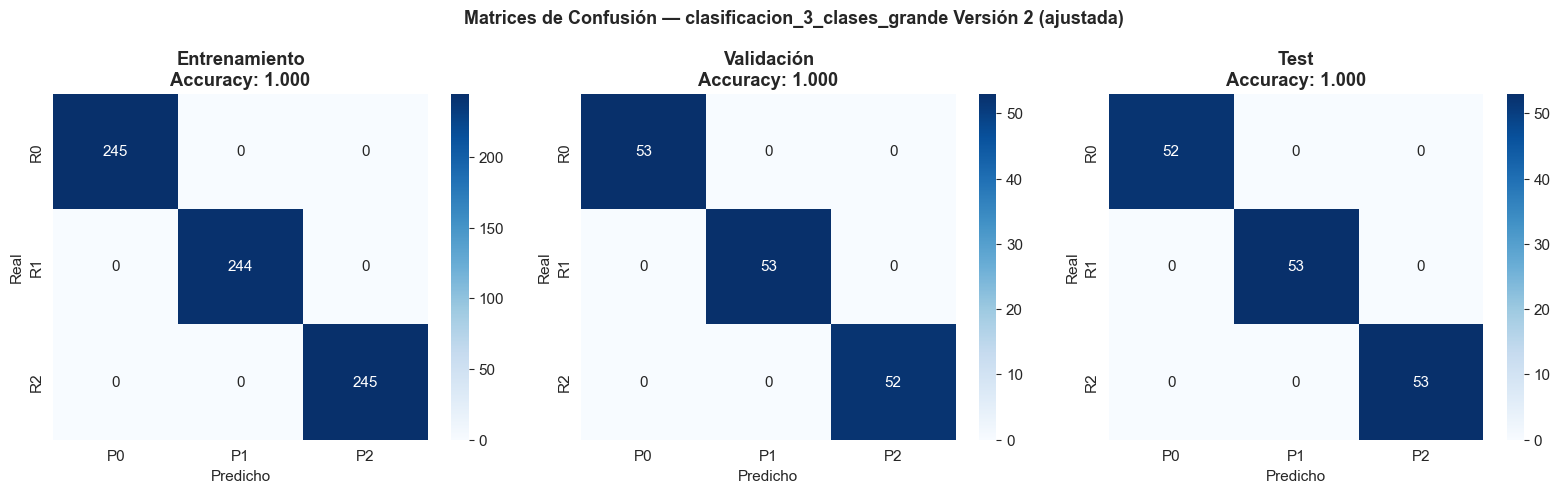

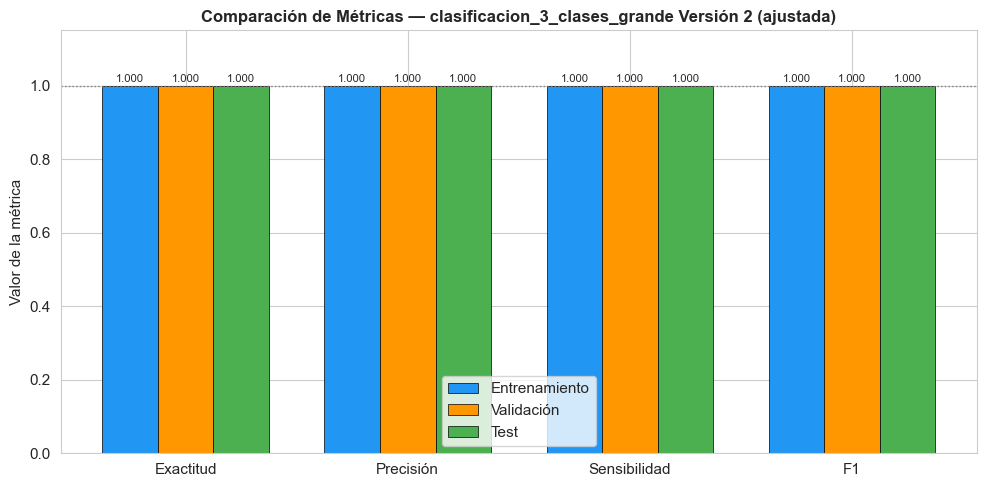

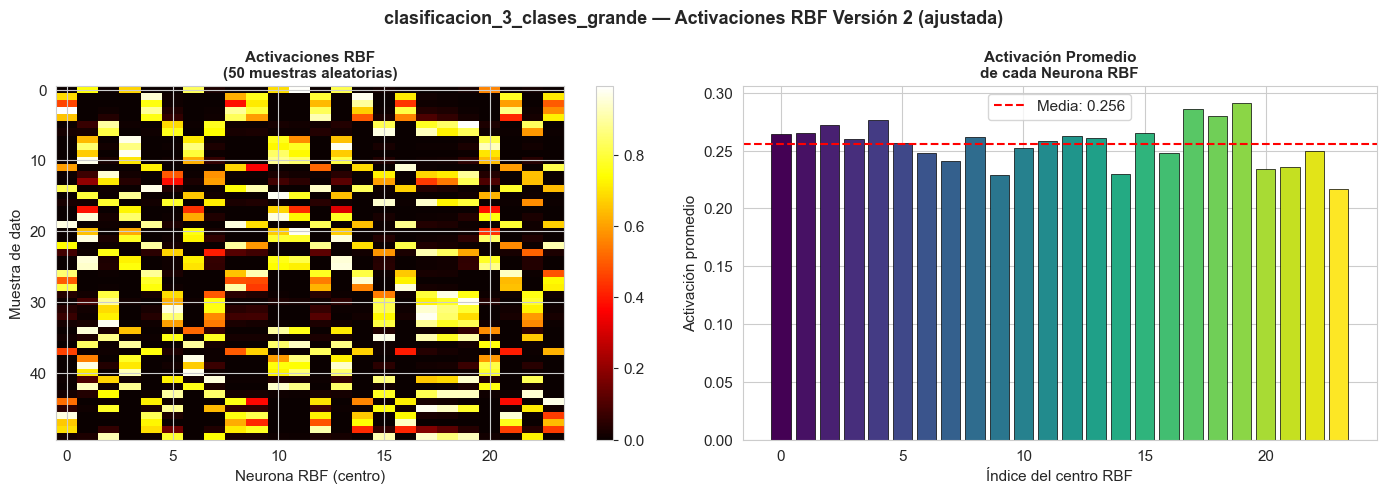

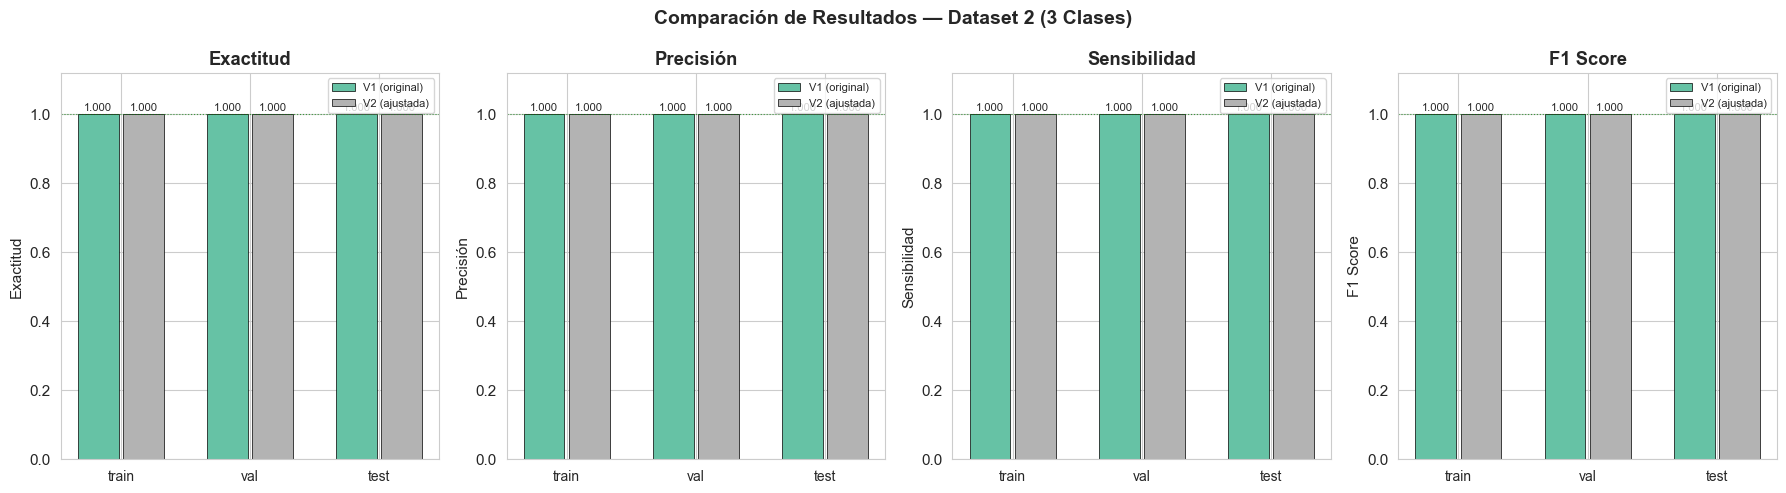

In [10]:
PARAMS_DS2_V2 = {
    'n_centros'   : 24,
    'sigma'       : None,
    'C'           : 10.0,
    'particion'   : '70-15-15',
    'random_state': 42
}

modelo_ds2_v2, metricas_ds2_v2 = pipeline_completo(
    RUTA_DS2,
    nombre_version='Versión 2 (ajustada)',
    **PARAMS_DS2_V2
)

graficar_comparacion_resultados(
    [('V1 (original)', metricas_ds2_v1),
     ('V2 (ajustada)', metricas_ds2_v2)],
    titulo='Dataset 2 (3 Clases)'
)

---
# DATASET 3 — Clasificación con 4 clases
**Contexto:** Niveles de riesgo: bajo (0), medio-bajo (1), medio-alto (2), alto (3)  
**Variables:** x1, x2, x3, x4 (4 variables)  
**Datos:** 1200 muestras (300 por clase)

---


#################################################################
  PIPELINE RBF — Versión 1
#################################################################

Cargando dataset...
   Dataset: clasificacion_4_clases_grande
   Forma de X: (1200, 4)  (filas=muestras, columnas=variables)
   Clases en y: [0 1 2 3]

Parámetros de entrada definidos:
   • n_centros    = 16  (neuronas en la capa RBF)
   • sigma        = automático
   • C (regulariz)= 1.0
   • Partición    = 80-10-10
   • random_state = 42

Estadística descriptiva:

  ESTADÍSTICA DESCRIPTIVA — clasificacion_4_clases_grande
  • Total de muestras : 1200
  • Número de features: 4 → ['x1', 'x2', 'x3', 'x4']
  • Clases            : [0 1 2 3]
  • Muestras por clase: {np.int64(0): np.int64(300), np.int64(1): np.int64(300), np.int64(2): np.int64(300), np.int64(3): np.int64(300)}

  Estadísticas por variable:
             x1        x2        x3        x4
count  1200.000  1200.000  1200.000  1200.000
mean      6.980     6.999     7.031  

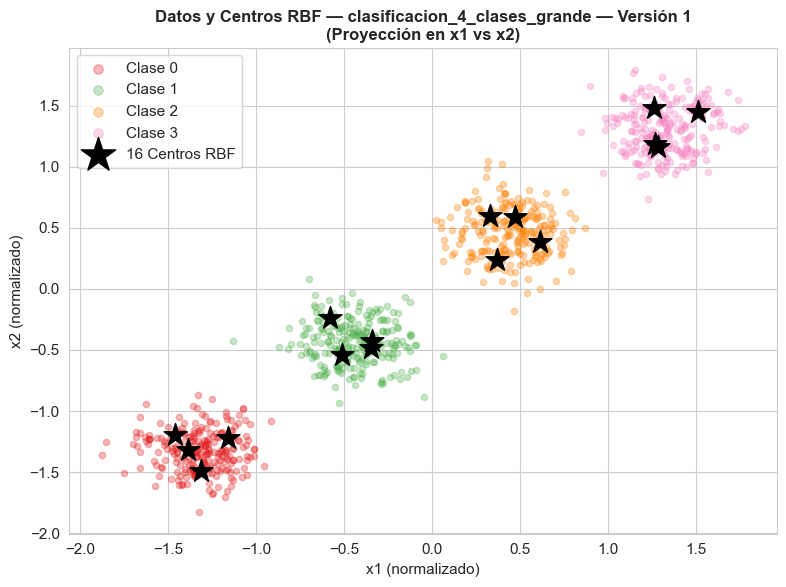


Simulando (prediciendo) en los 3 conjuntos:
   Ejemplo (primeras 5 muestras del conjunto de validación):
   Real    : [1 2 1 1 0]
   Predicho: [1 2 1 1 0]

Métricas de evaluación:

  📊 MÉTRICAS — ENTRENAMIENTO
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └─────────────────────────────────────┘

  📊 MÉTRICAS — VALIDACIÓN
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └─────────────────────────────────────┘

  📊 MÉTRICAS — PRUEBA (TEST)
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └───────────────────────────

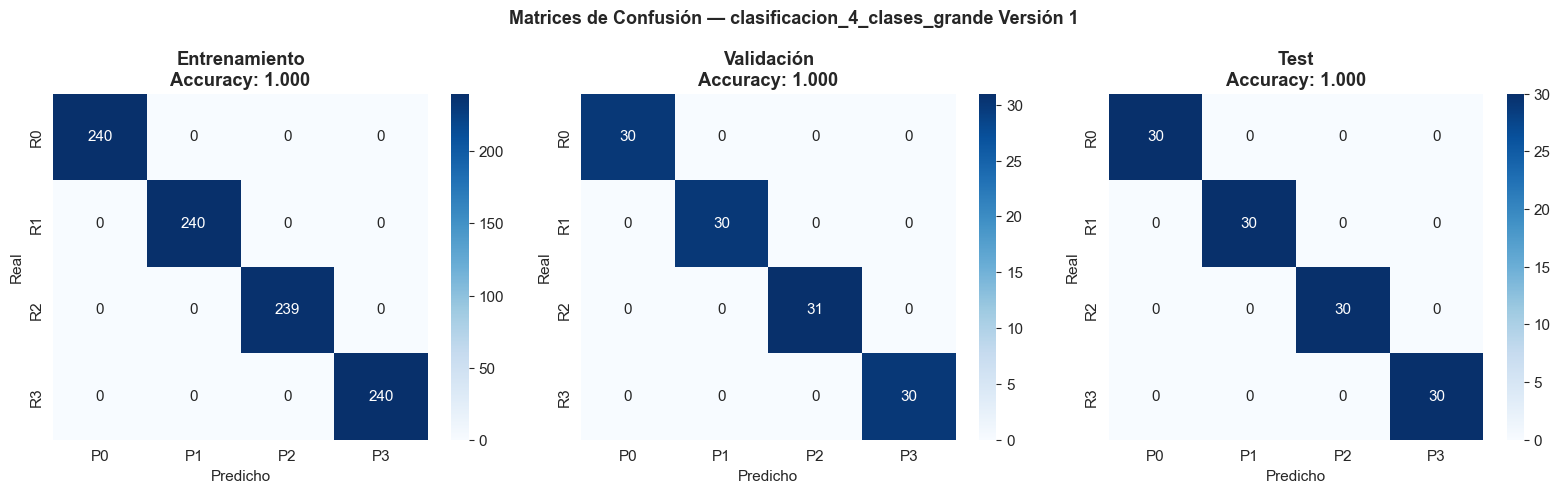

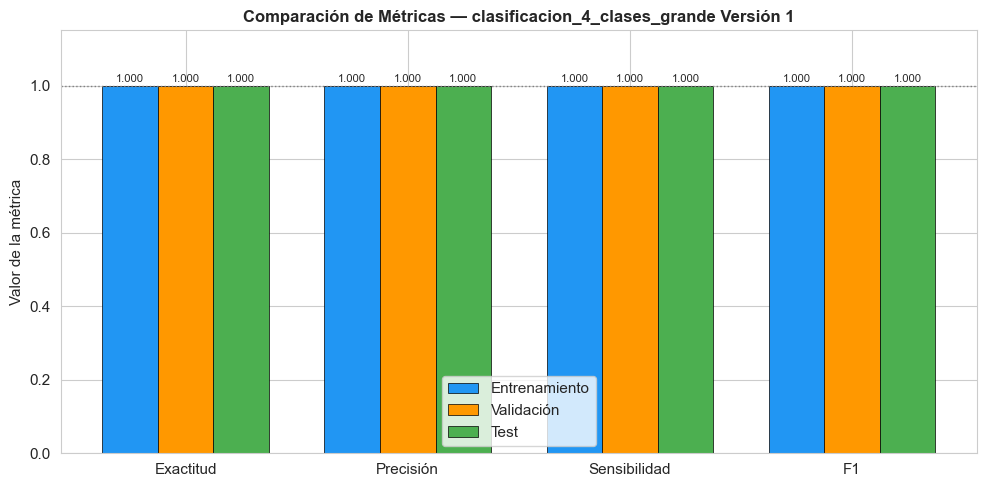

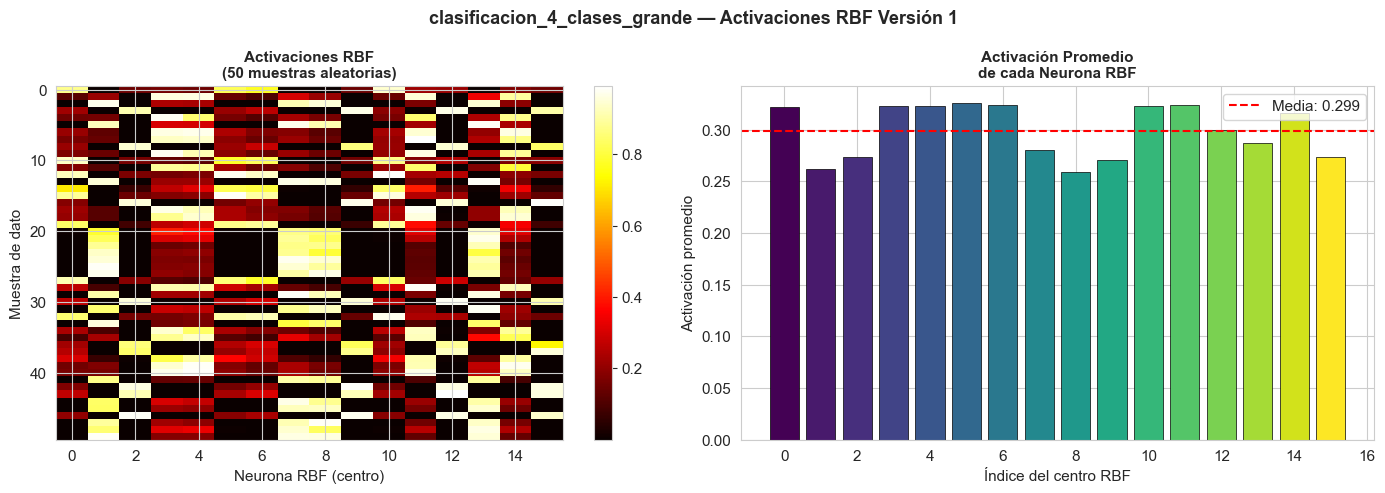

In [11]:
RUTA_DS3 = 'dataset_rbf_3.json'  

PARAMS_DS3_V1 = {
    'n_centros'   : 16,         
    'sigma'       : None,
    'C'           : 1.0,
    'particion'   : '80-10-10',
    'random_state': 42
}

modelo_ds3_v1, metricas_ds3_v1 = pipeline_completo(
    RUTA_DS3,
    nombre_version='Versión 1',
    **PARAMS_DS3_V1
)


#################################################################
  PIPELINE RBF — Versión 2 (ajustada)
#################################################################

Cargando dataset...
   Dataset: clasificacion_4_clases_grande
   Forma de X: (1200, 4)  (filas=muestras, columnas=variables)
   Clases en y: [0 1 2 3]

Parámetros de entrada definidos:
   • n_centros    = 32  (neuronas en la capa RBF)
   • sigma        = automático
   • C (regulariz)= 5.0
   • Partición    = 70-15-15
   • random_state = 42

Estadística descriptiva:

  ESTADÍSTICA DESCRIPTIVA — clasificacion_4_clases_grande
  • Total de muestras : 1200
  • Número de features: 4 → ['x1', 'x2', 'x3', 'x4']
  • Clases            : [0 1 2 3]
  • Muestras por clase: {np.int64(0): np.int64(300), np.int64(1): np.int64(300), np.int64(2): np.int64(300), np.int64(3): np.int64(300)}

  Estadísticas por variable:
             x1        x2        x3        x4
count  1200.000  1200.000  1200.000  1200.000
mean      6.980     6.999 

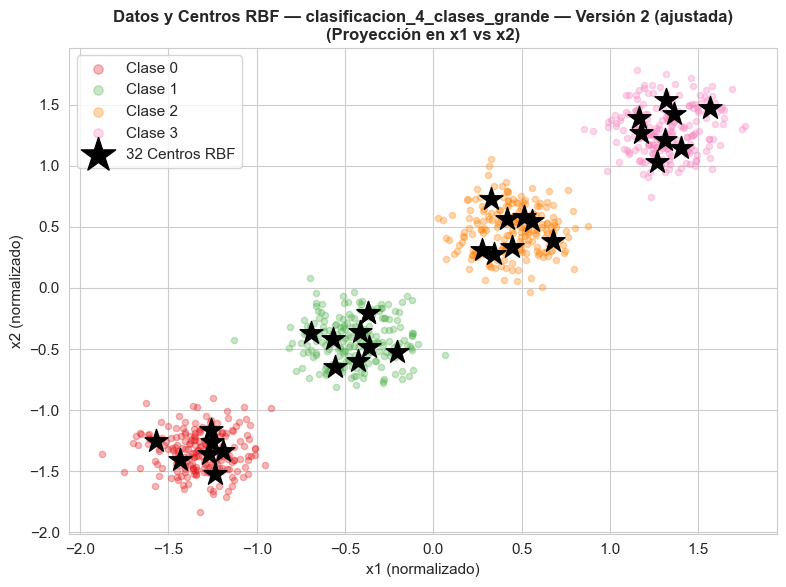


Simulando (prediciendo) en los 3 conjuntos:
   Ejemplo (primeras 5 muestras del conjunto de validación):
   Real    : [2 1 0 2 0]
   Predicho: [2 1 0 2 0]

Métricas de evaluación:

  📊 MÉTRICAS — ENTRENAMIENTO
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └─────────────────────────────────────┘

  📊 MÉTRICAS — VALIDACIÓN
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └─────────────────────────────────────┘

  📊 MÉTRICAS — PRUEBA (TEST)
  ┌─────────────────────────────────────┐
  │  Exactitud   (Accuracy)  : 1.0000  │
  │  Precisión   (Precision) : 1.0000  │
  │  Sensibilidad (Recall)   : 1.0000  │
  │  F1 Score                : 1.0000  │
  └───────────────────────────

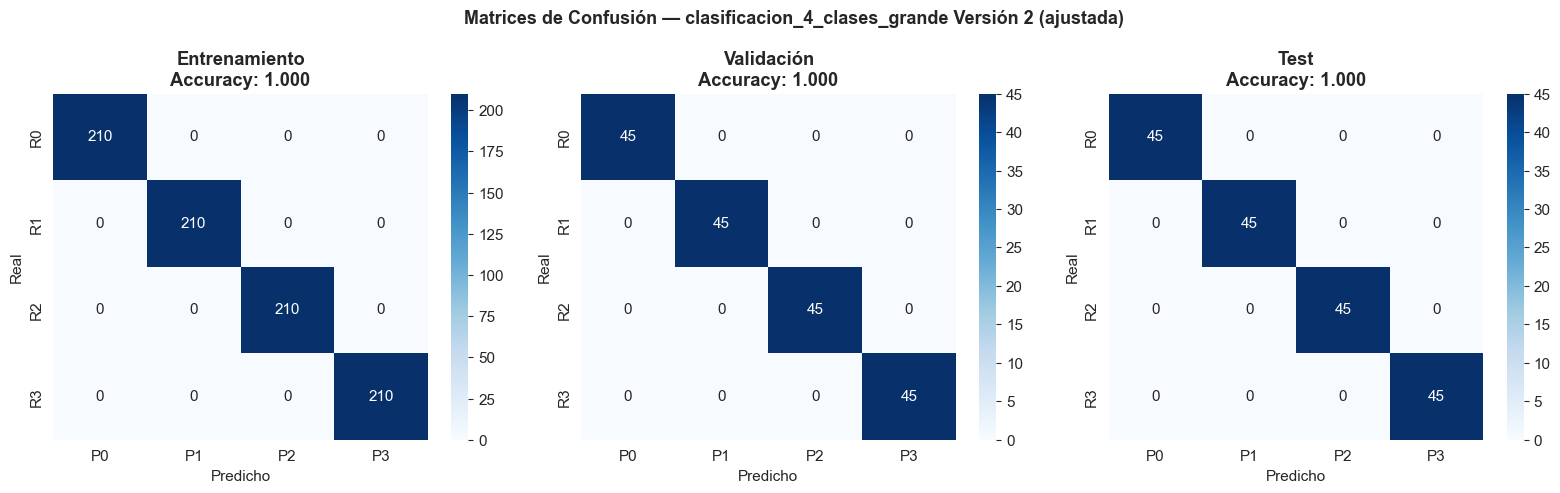

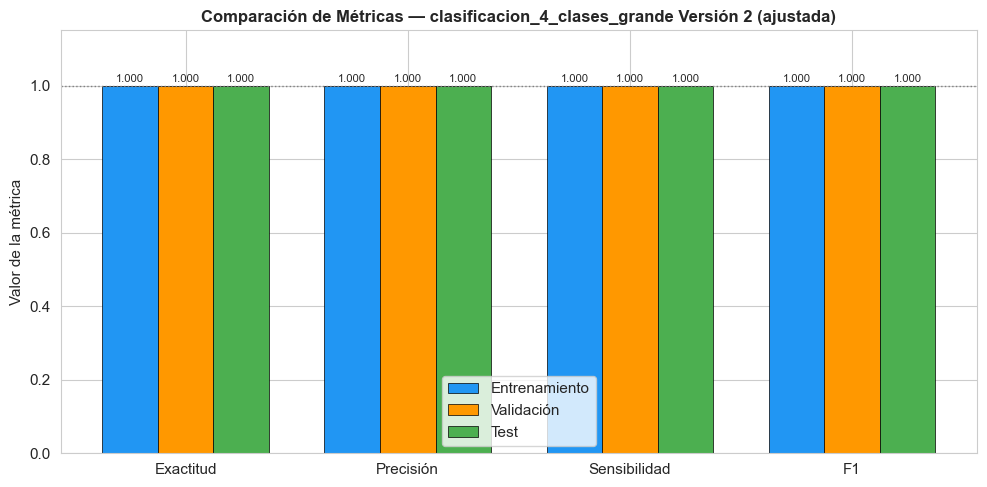

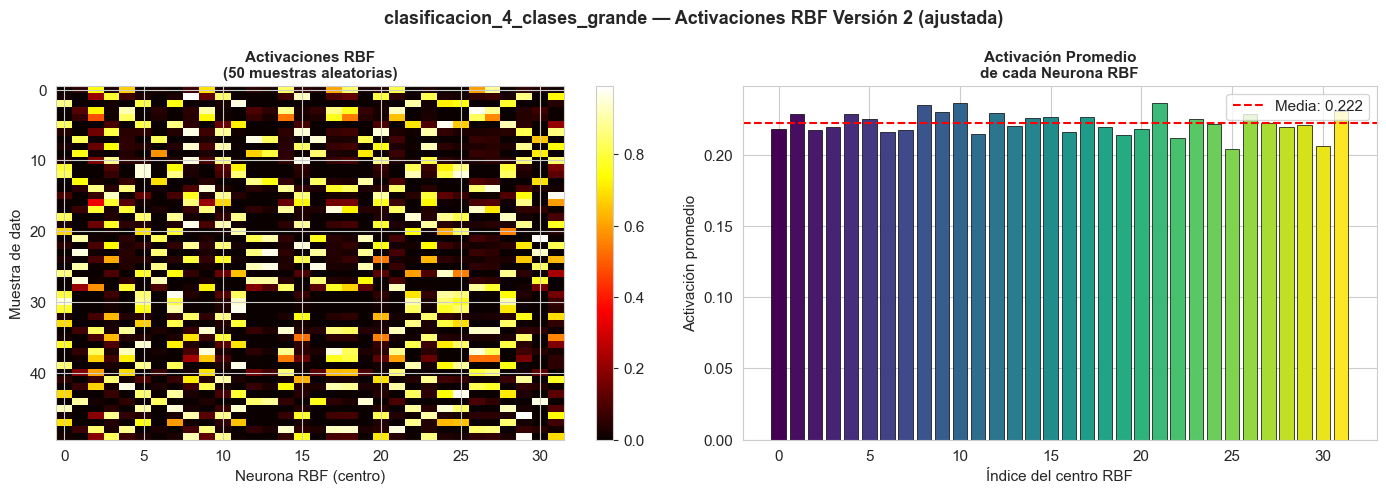

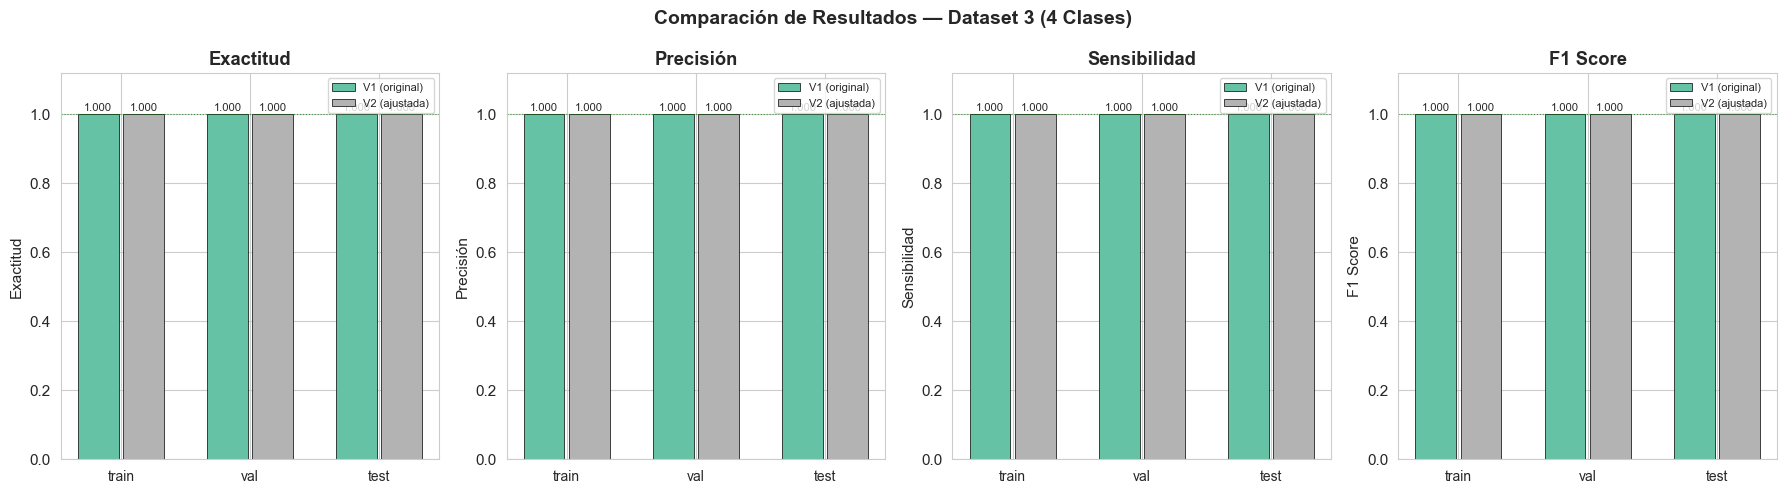

In [12]:
PARAMS_DS3_V2 = {
    'n_centros'   : 32,
    'sigma'       : None,
    'C'           : 5.0,
    'particion'   : '70-15-15',
    'random_state': 42
}

modelo_ds3_v2, metricas_ds3_v2 = pipeline_completo(
    RUTA_DS3,
    nombre_version='Versión 2 (ajustada)',
    **PARAMS_DS3_V2
)

graficar_comparacion_resultados(
    [('V1 (original)', metricas_ds3_v1),
     ('V2 (ajustada)', metricas_ds3_v2)],
    titulo='Dataset 3 (4 Clases)'
)

---
# RESUMEN FINAL

  RESUMEN FINAL — MEJORES MODELOS POR DATASET
Modelo                              Centros     C    Train      Val     Test
---------------------------------------------------------------------------
Dataset 1 (2 clases) — V1                 8   1.0   1.0000   1.0000   1.0000
Dataset 1 (2 clases) — V2                16   5.0   1.0000   1.0000   1.0000
Dataset 2 (3 clases) — V1                12   1.0   1.0000   1.0000   1.0000
Dataset 2 (3 clases) — V2                24  10.0   1.0000   1.0000   1.0000
Dataset 3 (4 clases) — V1                16   1.0   1.0000   1.0000   1.0000
Dataset 3 (4 clases) — V2                32   5.0   1.0000   1.0000   1.0000



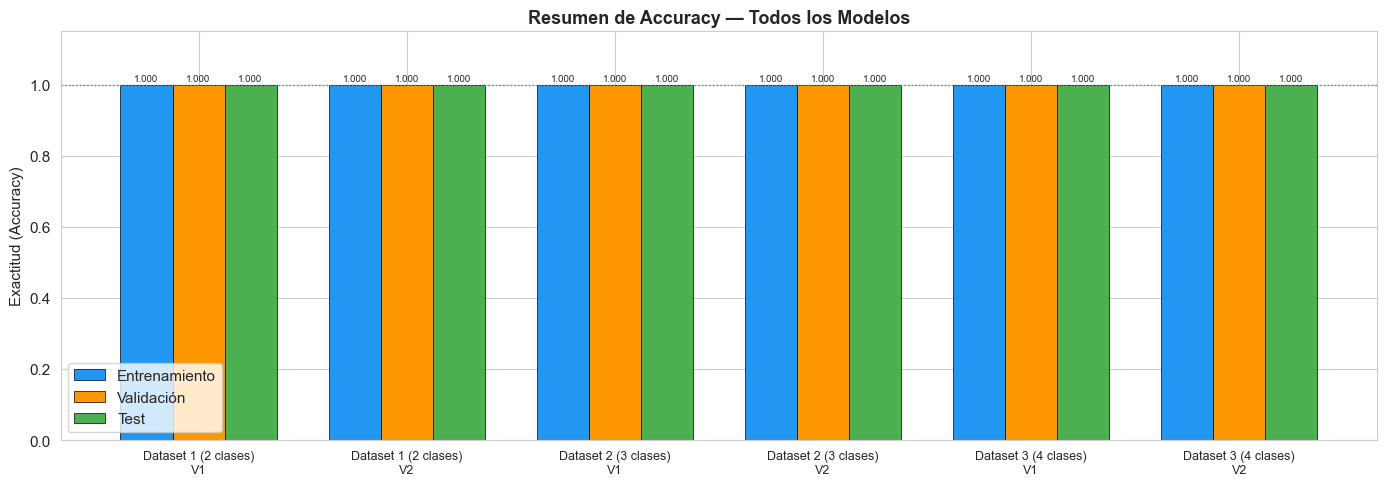


¡Análisis completo!


In [13]:
print('='*75)
print('  RESUMEN FINAL — MEJORES MODELOS POR DATASET')
print('='*75)

todos = [
    ('Dataset 1 (2 clases) — V1', metricas_ds1_v1, PARAMS_DS1_V1),
    ('Dataset 1 (2 clases) — V2', metricas_ds1_v2, PARAMS_DS1_V2),
    ('Dataset 2 (3 clases) — V1', metricas_ds2_v1, PARAMS_DS2_V1),
    ('Dataset 2 (3 clases) — V2', metricas_ds2_v2, PARAMS_DS2_V2),
    ('Dataset 3 (4 clases) — V1', metricas_ds3_v1, PARAMS_DS3_V1),
    ('Dataset 3 (4 clases) — V2', metricas_ds3_v2, PARAMS_DS3_V2),
]

print(f'{"Modelo":<35} {"Centros":>7} {"C":>5} {"Train":>8} {"Val":>8} {"Test":>8}')
print('-'*75)
for nombre, mets, params in todos:
    print(f'{nombre:<35} {params["n_centros"]:>7} {params["C"]:>5} '
          f'{mets["train"]["accuracy"]:>8.4f} '
          f'{mets["val"]["accuracy"]:>8.4f} '
          f'{mets["test"]["accuracy"]:>8.4f}')

print('='*75)
print()

# Gráfica resumen final
fig, ax = plt.subplots(figsize=(14, 5))

nombres = [n.replace(' — ', '\n') for n, _, _ in todos]
trains = [m['train']['accuracy'] for _, m, _ in todos]
vals   = [m['val']['accuracy'] for _, m, _ in todos]
tests  = [m['test']['accuracy'] for _, m, _ in todos]

x = np.arange(len(nombres))
w = 0.25

ax.bar(x - w, trains, w, label='Entrenamiento', color='#2196F3', edgecolor='black', lw=0.5)
ax.bar(x,     vals,   w, label='Validación',    color='#FF9800', edgecolor='black', lw=0.5)
ax.bar(x + w, tests,  w, label='Test',           color='#4CAF50', edgecolor='black', lw=0.5)

ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=9)
ax.set_ylabel('Exactitud (Accuracy)', fontsize=11)
ax.set_title('Resumen de Accuracy — Todos los Modelos', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend()
ax.axhline(1.0, color='gray', linestyle=':', lw=1)

for i, (t, v, ts) in enumerate(zip(trains, vals, tests)):
    ax.text(i-w, t+0.005, f'{t:.3f}', ha='center', va='bottom', fontsize=7)
    ax.text(i,   v+0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=7)
    ax.text(i+w, ts+0.005,f'{ts:.3f}',ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

print('\n¡Análisis completo!')

---
# GUÍA DE INTERPRETACIÓN

## ¿Cómo saber si el modelo está bien?

| Situación | Qué significa | Qué hacer |
|-----------|---------------|----------|
| Train alto, Test bajo | **Sobreajuste** (memorizó) | Reducir n_centros, aumentar C pequeño |
| Train bajo, Test bajo | **Subajuste** (no aprendió) | Aumentar n_centros, aumentar C |
| Train ≈ Val ≈ Test altos | **¡Perfecto!** | El modelo generaliza bien |

## ¿Qué significa cada métrica?

- **Exactitud (Accuracy)**: De 100 pacientes, ¿a cuántos diagnostiqué bien?
- **Precisión (Precision)**: De los que dije "tiene la enfermedad", ¿cuántos realmente la tenían?
- **Sensibilidad (Recall)**: De todos los enfermos reales, ¿cuántos detecté?
- **F1 Score**: Balance entre precisión y sensibilidad. El más importante cuando las clases están balanceadas.

## Valores de referencia

| Valor | Calidad |
|-------|--------|
| > 0.95 | Excelente |
| 0.85-0.95 | Bueno |
| 0.70-0.85 | Aceptable |
| < 0.70 | Necesita mejorar |

## Parámetros recomendados para empezar

| Dataset | n_centros inicial | C recomendado |
|---------|-------------------|---------------|
| 2 clases | 6–10 | 1.0 |
| 3 clases | 9–15 | 1.0–5.0 |
| 4 clases | 12–20 | 1.0–5.0 |